In [1]:
import shutil
#zipping folder
shutil.make_archive('/content/My_new_ultralytics_folder', 'zip', '/content/drive/MyDrive/My_new_ultralytics_folder')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/My_new_ultralytics_folder'

In [ ]:
from google.colab import files
files.download('/content/My_new_ultralytics_folder.zip')
#download folder

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
pip install scikit-learn

In [3]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.3 MB/s eta 0:00:00


In [4]:
!pip install albumentations

pip is a  package manager we use to install external libraries so here we are installing libraries we need in our environment

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


when we want to acess a folder in google collab we first upload that folder in drive so here we are mounting drive in google collab

In [8]:
from google.colab import files
uploaded = files.upload()

Saving glass85.jpg to glass85.jpg
Saving glass89.jpg to glass89.jpg
Saving glass156.jpg to glass156.jpg
Saving metal192.jpg to metal192.jpg
Saving metal298.jpg to metal298.jpg
Saving metal335.jpg to metal335.jpg
Saving organic_000171_photo.jpg to organic_000171_photo.jpg
Saving organic_000204_photo.jpg to organic_000204_photo.jpg
Saving organic20.jpg to organic20.jpg
Saving paper140.jpg to paper140.jpg
Saving paper313.jpg to paper313.jpg
Saving paper392.jpg to paper392.jpg
Saving plastic123.jpg to plastic123.jpg
Saving plastic214.jpg to plastic214.jpg
Saving plastic281.jpg to plastic281.jpg


here we are uploading files (images) directly from our computer

In [9]:
import subprocess
subprocess.run(['umount', '/content/drive'])

CompletedProcess(args=['umount', '/content/drive'], returncode=0)

unmount(disconnacting) google drive and google colab

In [10]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


remounting/reconnecting

In [11]:
import os
os.listdir('/content/')

['.config',
 'organic20.jpg',
 'metal298.jpg',
 'organic_000171_photo.jpg',
 'glass85.jpg',
 'plastic123.jpg',
 'glass156.jpg',
 'drive',
 'metal192.jpg',
 'plastic281.jpg',
 'paper140.jpg',
 'plastic214.jpg',
 'organic_000204_photo.jpg',
 'glass89.jpg',
 'paper392.jpg',
 'metal335.jpg',
 'paper313.jpg',
 'sample_data']

listing all the files and folder currently our workspace have

In [12]:
# Importing all required libraries and tools
from ultralytics import YOLO
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
%matplotlib inline
import os
from torchvision import datasets
import cv2
import random
import shutil
import albumentations as A

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


1.   importing yolo model from ultralytics to load and train model
2.   importing torch because yolo's pre-trained model is based on this framework
1.   sklearn.metrics is a library we use its functions to compute confusion matrices and to display them visually
2.   we use Matplotlib to display charts,images etc visually.
1.   we use %matplotlib inline in pythin environment to show output directly in the output cell instead of in seprate window


1.   importng image modeule from PIL library to process images
2.   we use numpy to handle arrays and advanced methematical function
2.   os to handle files and folders


1.  torchvision.datasets : datasets is  a mdodule we are importing from torchvision library which we use to load custom & standard datasets
2.  imports albumentations for data augmentation


1.  shutil to copy or move folders and files
2.   imports random to select images randomly when augmentation created


1.  cv2 to read ,modeify & save images especilly during augmentaion



















In [13]:
# Loading the dataset and printing the size and class names
data_dir = r'/content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x))
                  for x in ['train', 'val', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(dataset_sizes, class_names)

{'train': 1735, 'val': 169, 'test': 608} ['glass', 'metal', 'organic', 'paper', 'plastic']


it goes through our main dataset folder and then loads its subfolders tarin,val,test  and then counts the total number of iamges in test,train ,val folders and then it also reads the classes names from train folder and then prints total number of images in each subfolder and a list of classes names

In [14]:
#  Counting the number of images in each class
data_dir = '/content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset'
split = 'train'  # or 'val' or 'test'

split_path = os.path.join(data_dir, split)
for class_name in os.listdir(split_path):
    class_path = os.path.join(split_path, class_name)
    if os.path.isdir(class_path):
        num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"{class_name}: {num_images} images")


paper: 413 images
plastic: 334 images
glass: 347 images
metal: 284 images
organic: 357 images


this code is going in to train folder we have inside our main dataset folder ,checking each class (metal,plastic etc ) one by one .counting how many images each class has and printing the results(classes names and number of images in each class)

In [ ]:
!nvidia-smi #check if GPU is working

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
#import shutil
#to delete augmented folder
#shutil.rmtree('/content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset_augmented')

In [ ]:

# Augmenting the training data to have 1500 images per class and copying val/test as-is

base_dir = '/content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset'
output_dir = '/content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset_augmented'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

out_train_dir = os.path.join(output_dir, 'train')
out_val_dir = os.path.join(output_dir, 'val')
out_test_dir = os.path.join(output_dir, 'test')

target_images_per_class = 1500


transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=20, p=0.7),
    #A.RandomBrightnessContrast(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=0.8),
    A.RandomGamma(p=0.5), #Adjusts image lighting curve randomly
    A.CLAHE(p=0.4),#Improves local contrast, makes details clearer
    A.HueSaturationValue(p=0.5),#Changes color tone, saturation, and brightness
    A.GaussianBlur(p=0.3),#Applies slight blur to simulate unfocused images
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=20, p=0.5),#Randomly shifts position, zooms, and rotates image
])

os.makedirs(out_train_dir, exist_ok=True)
os.makedirs(out_val_dir, exist_ok=True)
os.makedirs(out_test_dir, exist_ok=True)

for split_src, split_dst in [(val_dir, out_val_dir), (test_dir, out_test_dir)]:
    for class_name in os.listdir(split_src):
        src_class_path = os.path.join(split_src, class_name)
        dst_class_path = os.path.join(split_dst, class_name)

        if not os.path.isdir(src_class_path):
            continue

        shutil.copytree(src_class_path, dst_class_path, dirs_exist_ok=True)

print("Val and Test copied without augmentation.")

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    out_class_path = os.path.join(out_train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    os.makedirs(out_class_path, exist_ok=True)

    image_files = [f for f in os.listdir(class_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    current_count = len(image_files)


    for img_file in image_files:
        shutil.copy(os.path.join(class_path, img_file),
                    os.path.join(out_class_path, img_file))

    if current_count == 0:
        continue

    if current_count < target_images_per_class:
        needed = target_images_per_class - current_count

        for i in range(needed):
            img_file = random.choice(image_files)
            img_path = os.path.join(class_path, img_file)

            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            augmented = transform(image=image)['image']

            new_name = f"{os.path.splitext(img_file)[0]}_aug_{i}.jpg"
            save_path = os.path.join(out_class_path, new_name)

            cv2.imwrite(save_path, cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))

    print(f"{class_name} augmented to {target_images_per_class} images.")

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Val and Test copied without augmentation.
paper augmented to 1500 images.
plastic augmented to 1500 images.
glass augmented to 1500 images.
metal augmented to 1500 images.
organic augmented to 1500 images.


this code is applying data augmentation on our orignal dataset it coppies test and val folders from our dataset folder and apply augmentation only on tarin folder.
for tarin folder--> it frst copies all the orignal images if each class and then it checks if any class inside train folder have less then 1500 images(including the old images) if yes it apply augmentation(flipping ,chnage brigness,rotating) on that class and generate images untill that class reaches 1500 images and saved it in a new folder so our orignal dataset remain as it is

In [ ]:
# Counting total images per class across all splits in the augmented dataset

class_counts = {}

for split in ['train', 'val', 'test']:
    split_path = os.path.join(output_dir, split)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if not os.path.isdir(class_path):
            continue
        num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        if class_name in class_counts:
            class_counts[class_name] += num_images
        else:
            class_counts[class_name] = num_images

for class_name, total in class_counts.items():

    print(f"{class_name}: {total} images in total")

NameError: name 'output_dir' is not defined

this code is counting total number of images for each class across all the folders(test,train,val) after augmentation in augmented folder

In [ ]:
# Training the YOLO model on the dataset and evaluating(validating) it on the test set
model = YOLO('yolo11n-cls.pt')

results = model.train(
   data='/content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset_augmented',
    epochs=10,
    imgsz=224,
    batch=4,
    device=0 if torch.cuda.is_available() else 'cpu',
    workers=4,
)


metrics = model.val(split='test')
print(f"Test Accuracy: {metrics.top1}")


model.save('yolo_trash_classifier.pt')

Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset_augmented, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, o



1.    Loading the pretrained yolo11n model
2.   tarining it for our dataset
1.   saving the model for later use

*   epochs:model will go through entore dataset 20 times
*   imgsz:every image will be resized to 224 x 224 pixels before training


*   batch: model will look for (will process)4 images at a time











In [ ]:
# Saving the trained model to Google Drive
model.save('/content/drive/MyDrive/My_new_ultralytics_folder/yolo_trash_classifier.pt')

In [ ]:
#Generate Confusion Matrix and Validation Plots
#model = YOLO('/content/drive/MyDrive/My_new_ultralytics_folder/yolo_trash_classifier.pt')
#results = model.val(split='test', plots=True)


Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
train: /content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset/train... found 1735 images in 5 classes ✅ 
val: /content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset/val... found 169 images in 5 classes ✅ 
test: /content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset/test... found 608 images in 5 classes ✅ 
test: Fast image access ✅ (ping: 0.9±0.8 ms, read: 6.2±2.1 MB/s, size: 15.3 KB)
test: Scanning /content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset/test... 608 images, 0 corrupt: 100% ━━━━━━━━━━━━ 608/608 150.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 38/38 2.4it/s 15.8s
                   all      0.911          1
Speed: 0.0ms preprocess, 13.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val4


Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
train: /content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset_augmented/train... found 7500 images in 5 classes ✅ 
val: /content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset_augmented/val... found 169 images in 5 classes ✅ 
test: /content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset_augmented/test... found 608 images in 5 classes ✅ 
test: Fast image access ✅ (ping: 1.2±1.0 ms, read: 6.4±5.9 MB/s, size: 15.3 KB)
test: Scanning /content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset_augmented/test... 608 images, 0 corrupt: 100% ━━━━━━━━━━━━ 608/608 110.9Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 38/38 2.4it/s 15.7s
                   all      0.921          1
Speed: 0.0ms preprocess, 13.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val2


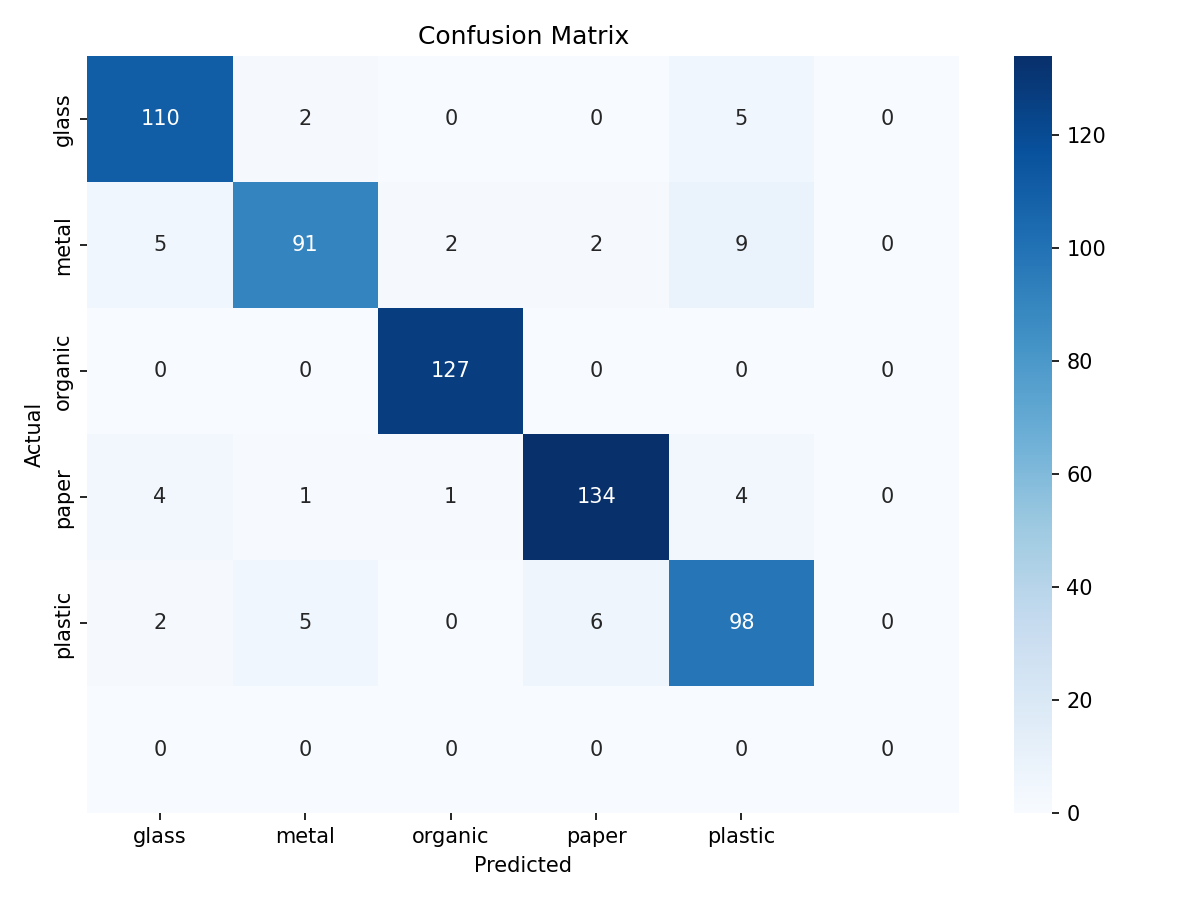

In [ ]:
#  Loading the model and plotting the confusion matrix
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns


model = YOLO('/content/drive/MyDrive/My_new_ultralytics_folder/yolo_trash_classifier.pt')
results = model.val(split='test')

cm = results.confusion_matrix.matrix
class_names = ['glass', 'metal', 'organic', 'paper', 'plastic']

plt.figure(figsize=(8, 6))
sns.heatmap(cm.astype(int),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

from IPython.display import Image
Image('confusion_matrix.png')

this code is loading the model from google drive and running it on test folder to get predictions
and the drawing a confusin matrix
confusion matrix is basically a table wich shows how well our model performed on each class it shows how many images were classified correctly and incorrectly. digonal numbers from top left to bottom right are the correct predictions evrything else are mistakes

In [ ]:
# Calculating TP, FP, FN, TN for each class from the confusion matrix

model = YOLO('/content/drive/MyDrive/My_new_ultralytics_folder/yolo_trash_classifier.pt')
results = model.val(split='test')

cm = results.confusion_matrix.matrix

class_names = ['glass', 'metal', 'organic', 'paper', 'plastic']
for i, class_name in enumerate(class_names):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    print(f"{class_name}: TP={TP}, FP={FP}, FN={FN}, TN={TN}")



Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
train: /content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset_augmented/train... found 7500 images in 5 classes ✅ 
val: /content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset_augmented/val... found 169 images in 5 classes ✅ 
test: /content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset_augmented/test... found 608 images in 5 classes ✅ 
test: Fast image access ✅ (ping: 0.7±0.2 ms, read: 6.4±3.9 MB/s, size: 15.3 KB)
test: Scanning /content/drive/MyDrive/My_new_ultralytics_folder/my_new_ultralyticsdataset_augmented/test... 608 images, 0 corrupt: 100% ━━━━━━━━━━━━ 608/608 150.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 38/38 2.5it/s 15.1s
                   all      0.921          1
Speed: 0.0ms preprocess, 12.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val3
glass: TP

this code is calculating TP,TN,FP,FN from confusion matrix we calculate them bcz these values helps us to see excatly where the model is making mistake

In [ ]:
#Calculate Precision, Recall, and F1-Score for Each Class
print("Class\tPrecision\tRecall\t\tF1-Score")
for i, class_name in enumerate(class_names):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP

    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f"{class_name}\t{precision:.4f}\t\t{recall:.4f}\t\t{f1:.4f}")

Class	Precision	Recall		F1-Score
glass	0.9091		0.9402		0.9244
metal	0.9192		0.8349		0.8750
organic	0.9769		1.0000		0.9883
paper	0.9437		0.9306		0.9371
plastic	0.8448		0.8829		0.8634


this code is calculating precision recall and F1 score from TP,TN,FP.

TP,FP,FN are raw numbers(model made 23 mistakes on plastic) of predictions and prediction
recall F1 score are percentages(model is 80% precise on plastic) of predictions
TN is not used in calculating these .
Because Precision, Recall and F1 only care about how well the model identifies a specific class and TN represents images that are "not that class" which is not relevant here.

In [ ]:
#Load Trained Model for Inference( for making predictions)
model = YOLO('/content/drive/MyDrive/My_new_ultralytics_folder/yolo_trash_classifier.pt')

inference means using pre-trained model to make predictions on new data

In [ ]:
#Running predictions on sample images and printing the predicted class
from PIL import Image
image_paths = [
    '/content/drive/MyDrive/My_new_ultralytics_folder/plastic123.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/organic20.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/glass156.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/metal298.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/organic_000204_photo.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/glass85.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/plastic214.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/glass89.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/organic_000171_photo.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/plastic281.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/metal335.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/paper392.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/paper140.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/paper313.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/metal192.jpg'
]

for image_path in image_paths:
    try:
        # Convert .jfif to .jpg if needed
        if image_path.endswith('.jfif'):
            img = Image.open(image_path)
            new_path = image_path.replace('.jfif', '.jpg')
            img.save(new_path)
            image_path = new_path

        results = model.predict(image_path)
        print(f"{image_path}: {results[0].names[results[0].probs.top1]}")
    except Exception as e:
        print(f"{image_path}: ERROR - {e}")


image 1/1 /content/drive/MyDrive/My_new_ultralytics_folder/plastic123.jpg: 224x224 plastic 0.69, metal 0.31, glass 0.00, paper 0.00, organic 0.00, 17.2ms
Speed: 4.5ms preprocess, 17.2ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
/content/drive/MyDrive/My_new_ultralytics_folder/plastic123.jpg: plastic

image 1/1 /content/drive/MyDrive/My_new_ultralytics_folder/organic20.jpg: 224x224 organic 1.00, plastic 0.00, metal 0.00, glass 0.00, paper 0.00, 17.3ms
Speed: 4.2ms preprocess, 17.3ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
/content/drive/MyDrive/My_new_ultralytics_folder/organic20.jpg: organic

image 1/1 /content/drive/MyDrive/My_new_ultralytics_folder/glass156.jpg: 224x224 glass 1.00, plastic 0.00, metal 0.00, paper 0.00, organic 0.00, 16.8ms
Speed: 4.2ms preprocess, 16.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
/content/drive/MyDrive/My_new_ultralytics_folder/glass156.jpg: glass

image 1/1 /content/drive/MyDrive

this code takes sample images from drive one by one convert them into jpg format of they are in jfif format then passes it to trained model wich looks at the image and predict wich class it belongs to and prints the image path along with the predicted class name If any image causes an error it prints the error message instead of crashing the entire code.

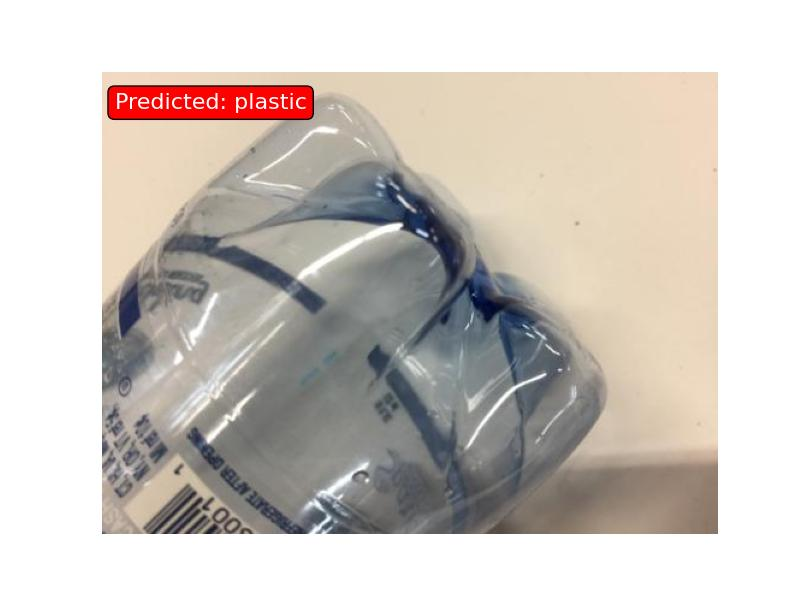

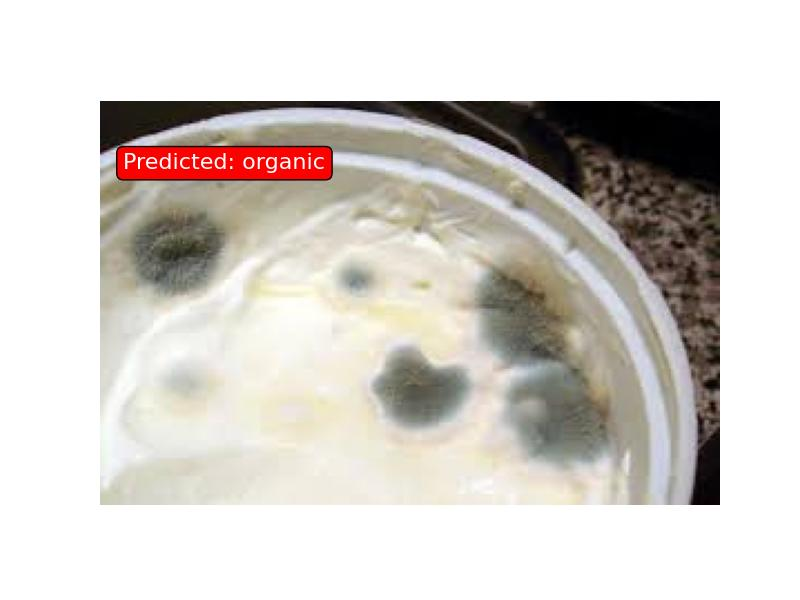

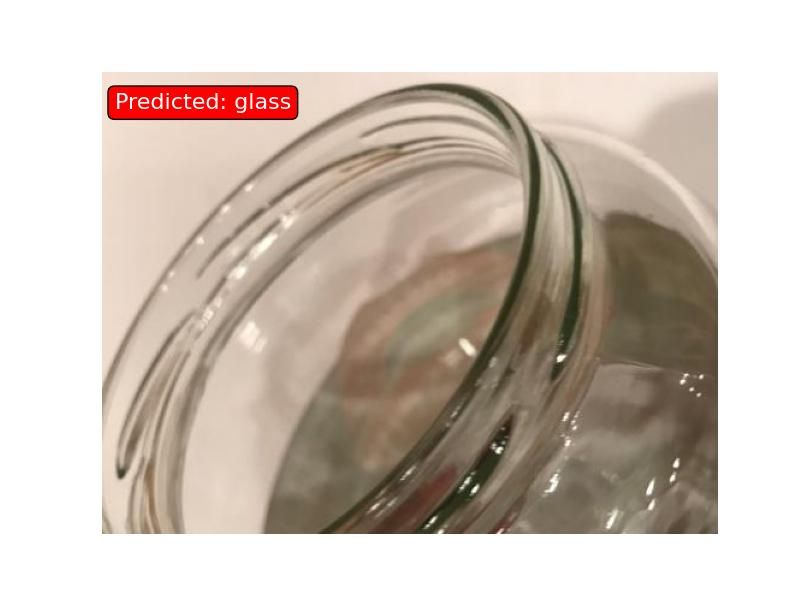

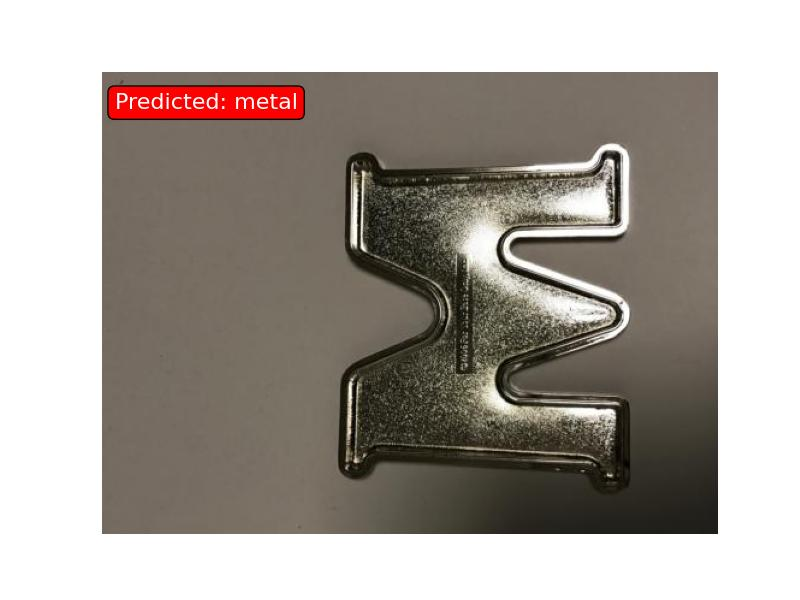

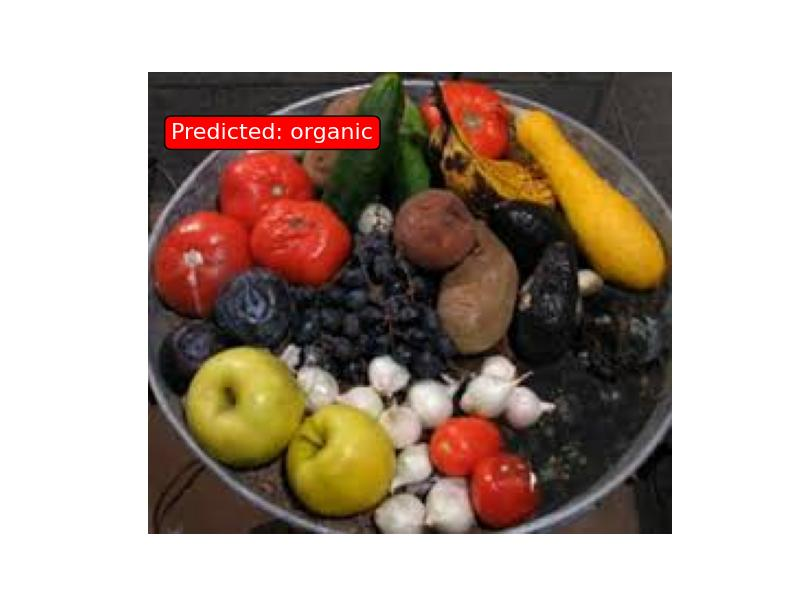

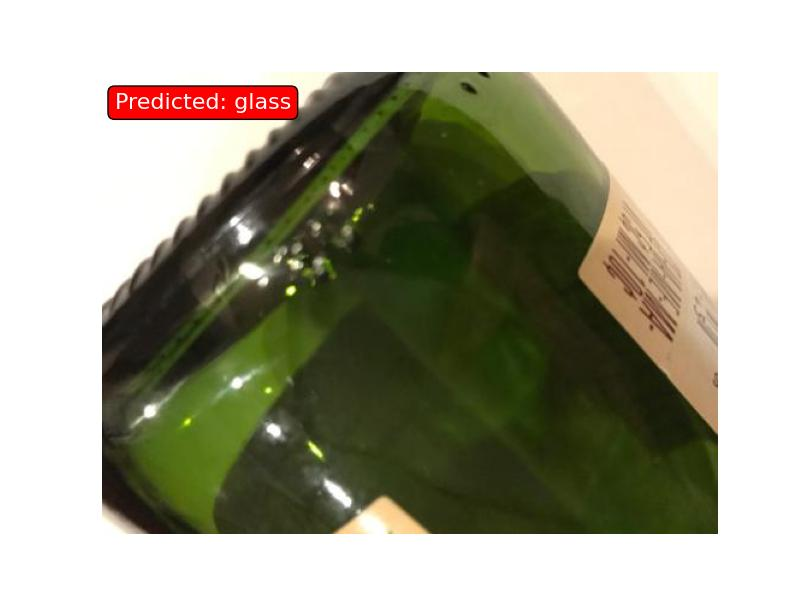

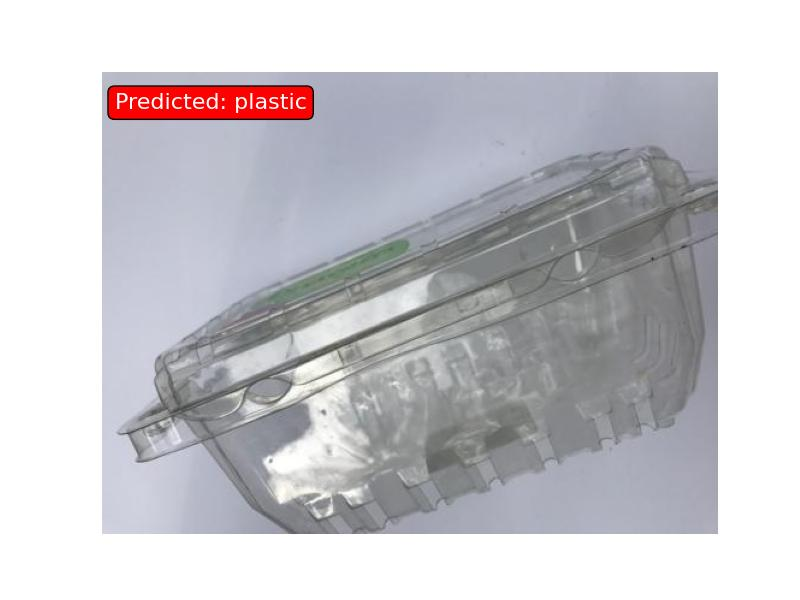

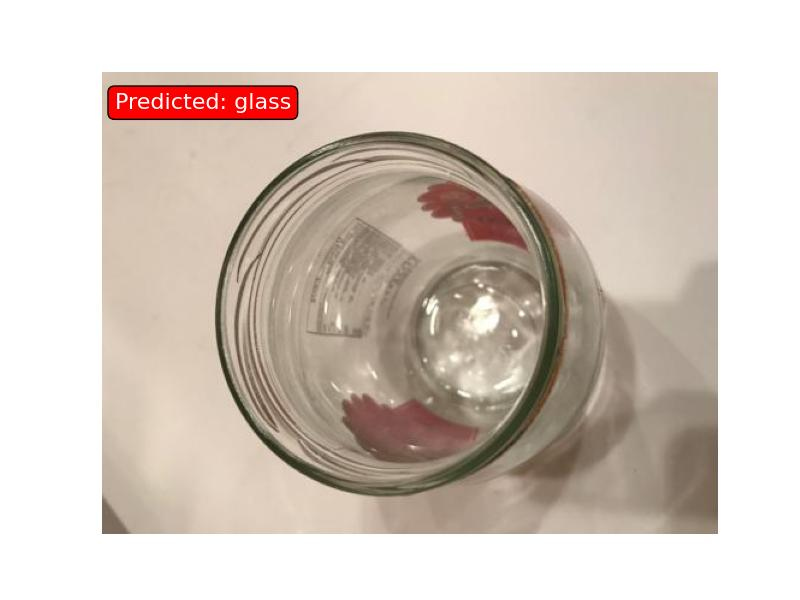

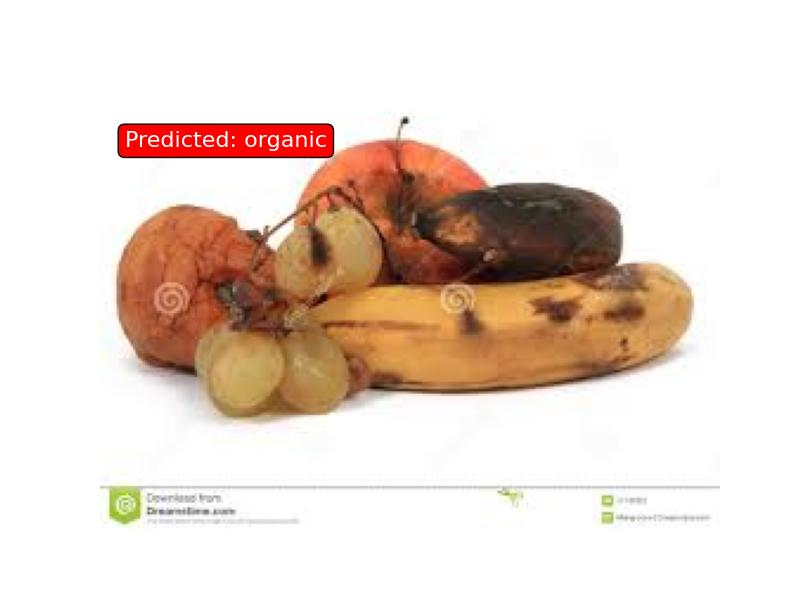

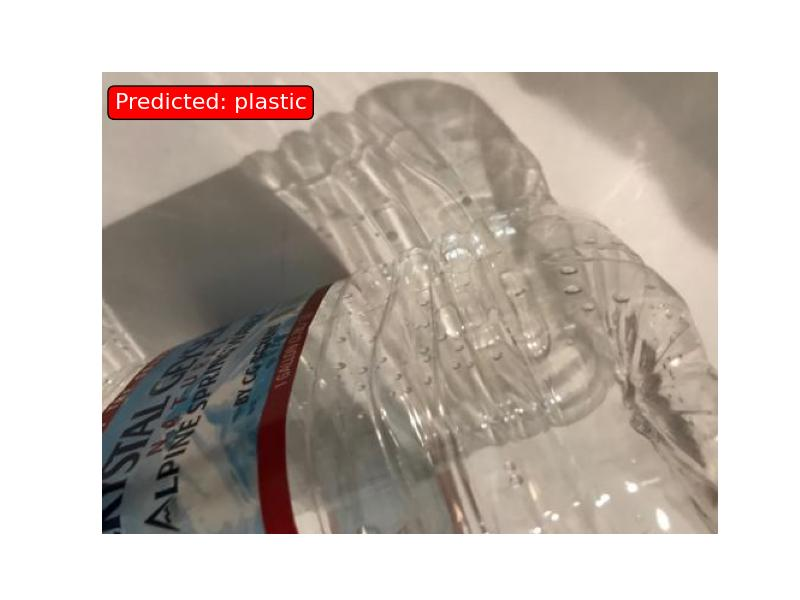

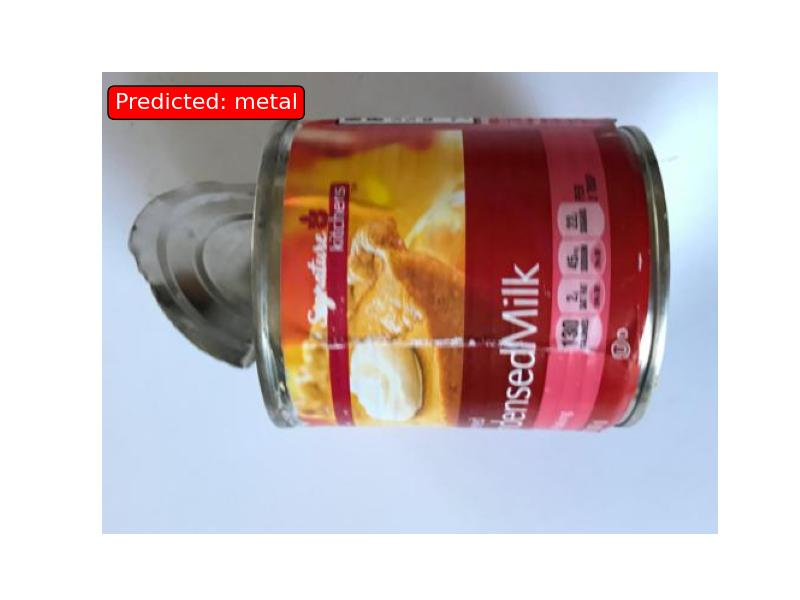

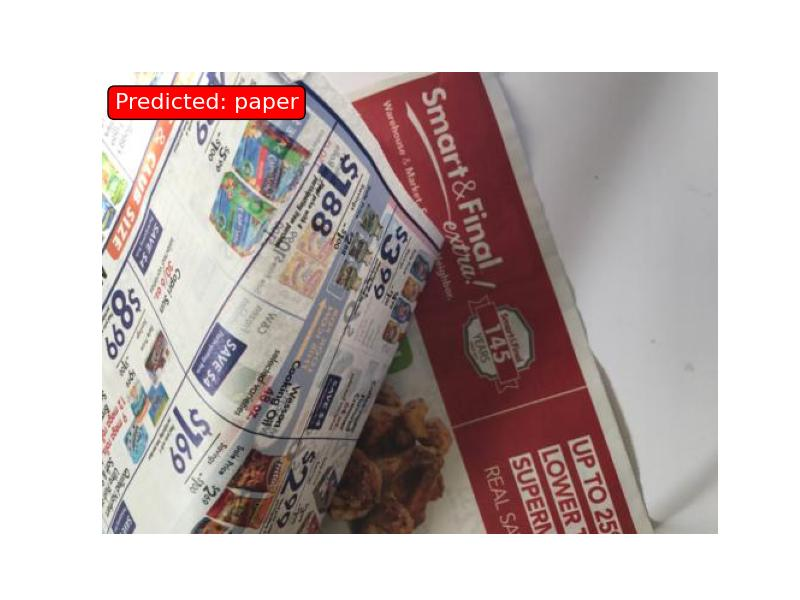

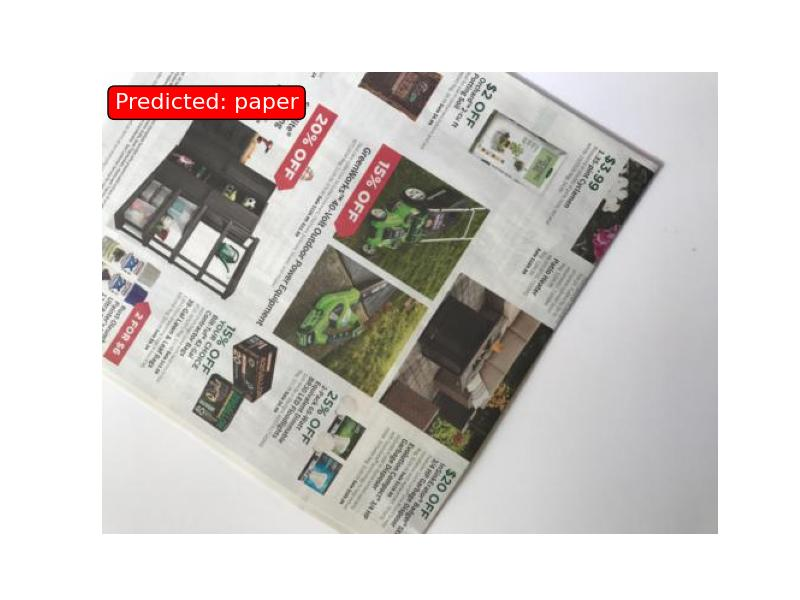

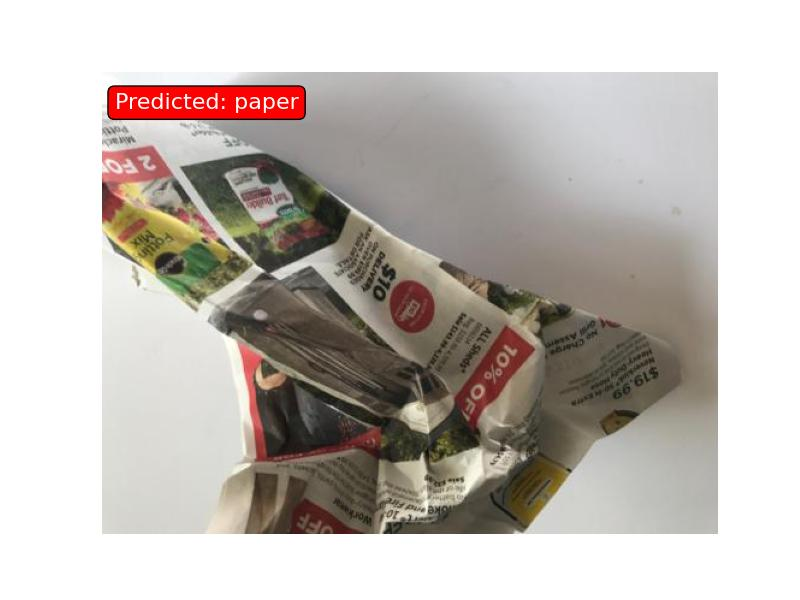

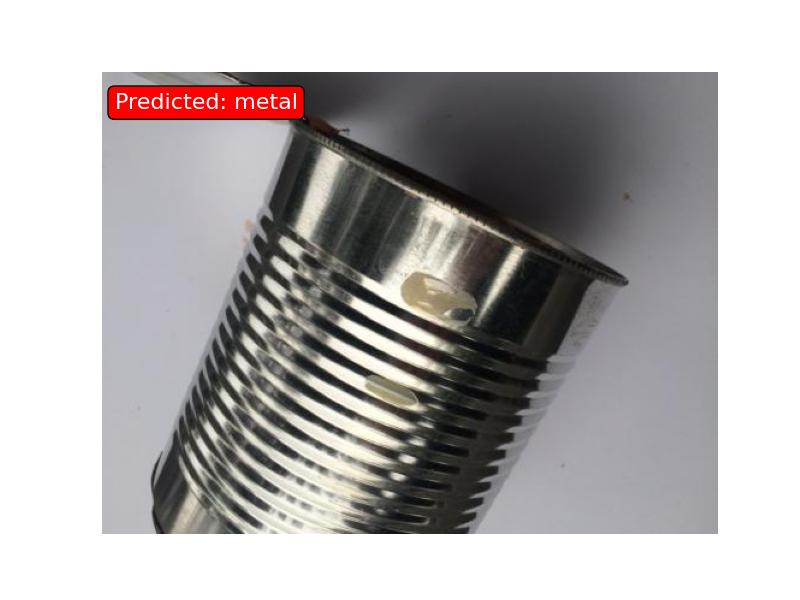

In [ ]:
#  Running predictions and displaying each image with the predicted label on it
from IPython.display import display as ipy_display, Image as IPyImage

model = YOLO('/content/drive/MyDrive/My_new_ultralytics_folder/yolo_trash_classifier.pt')

image_paths = [
    '/content/drive/MyDrive/My_new_ultralytics_folder/plastic123.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/organic20.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/glass156.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/metal298.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/organic_000204_photo.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/glass85.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/plastic214.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/glass89.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/organic_000171_photo.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/plastic281.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/metal335.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/paper392.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/paper140.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/paper313.jpg',
    '/content/drive/MyDrive/My_new_ultralytics_folder/metal192.jpg'
]

for image_path in image_paths:
    try:
        if image_path.endswith('.jfif'):
            img = Image.open(image_path)
            new_path = image_path.replace('.jfif', '.jpg')
            img.save(new_path)
            image_path = new_path

        results = model.predict(image_path, verbose=False)
        top1_conf = results[0].probs.top1conf.item()
        predicted = results[0].names[results[0].probs.top1]

        if top1_conf < 0.35:
            predicted = "Unknown"

        img = Image.open(image_path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.text(10, 30, f'Predicted: {predicted}', fontsize=16, color='white',
                 backgroundcolor='red', bbox=dict(boxstyle='round', facecolor='red'))
        plt.savefig(f'output_{os.path.basename(image_path)}')
        plt.close()

        ipy_display(IPyImage(f'output_{os.path.basename(image_path)}'))

    except Exception as e:
        print(f"{image_path}: ERROR - {e}")

this code is doing the same thing as the previous one but instead of just printing class name this code is displaying the image along with predicted class name label on it in a red box. also its checking if the confidence level of is below 35% predict it as unknow class instaed of predicting it as wrong class